# Transformadores con Keras
En este laboratorio vamos a usar transformadores para traducir textos del Inglés al Español

### SETUP

In [ ]:
!pip install -q tensorflow_cpu==2.17.1
!pip install -q matplotlib==3.9.2

In [2]:
import os
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import numpy as np
from keras.models import Model
from keras.layers import Input, LSTM, Dense, Embedding, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import backend as K
from keras.layers import Layer
import warnings
warnings.simplefilter('ignore', FutureWarning)

## Dataset

Definamos nuestro "dataset" con algunas traducciones manuales 

In [3]:
# Sample sentences 
input_texts = [
    "Hello.", "How are you?", "I live in Argentina.", "And what have you been up to?", "I like nature.", "I have a few pets."
]
target_texts = [
    "Hola.", "¿Cómo estás?", "Vivo en Argentina.", "¿Y qué estuviste haciendo?", "Me gusta la naturaleza.", "Tengo algunas mascotas."
]

target_texts = ["startseq " + x + " endseq" for x in target_texts]

Ahora tokenizamos las frases, recordemos que esto no necesariamente es 1 token = 1 palabra.

In [4]:
# Tokenization
input_tokenizer = Tokenizer()
input_tokenizer.fit_on_texts(input_texts)
input_sequences = input_tokenizer.texts_to_sequences(input_texts)

output_tokenizer = Tokenizer()
output_tokenizer.fit_on_texts(target_texts)
output_sequences = output_tokenizer.texts_to_sequences(target_texts)

input_vocab_size = len(input_tokenizer.word_index) + 1
output_vocab_size = len(output_tokenizer.word_index) + 1

Para mantener una simetría en los datos hacemos que todas las frases tengan la misma longitud.

In [5]:
# Padding
max_input_length = max([len(seq) for seq in input_sequences])
max_output_length = max([len(seq) for seq in output_sequences])

input_sequences = pad_sequences(input_sequences, maxlen=max_input_length, padding='post')
output_sequences = pad_sequences(output_sequences, maxlen=max_output_length, padding='post')

In [6]:
# Prepare the target data for training
decoder_input_data = output_sequences[:, :-1]
decoder_output_data = output_sequences[:, 1:]

# Convert to one-hot
decoder_output_data = np.array([np.eye(output_vocab_size)[seq] for seq in decoder_output_data])

## Creación del Modelo

Vimos anteriormente que nuestro modelo requiere de una serie de pasos para poder procesar información, acá tenemos una implementación de la capa de atención

### Self Attention


In [7]:
from tensorflow.keras.layers import Layer
from tensorflow.keras import backend as K

class SelfAttention(Layer):
    def __init__(self, **kwargs):
        super(SelfAttention, self).__init__(**kwargs)

    def build(self, input_shape):
        # input_shape is a list: [q_shape, k_shape, v_shape]
        feature_dim = input_shape[0][-1]

        self.Wq = self.add_weight(
            shape=(feature_dim, feature_dim),
            initializer='glorot_uniform',
            trainable=True,
            name='Wq'
        )

        self.Wk = self.add_weight(
            shape=(feature_dim, feature_dim),
            initializer='glorot_uniform',
            trainable=True,
            name='Wk'
        )

        self.Wv = self.add_weight(
            shape=(feature_dim, feature_dim),
            initializer='glorot_uniform',
            trainable=True,
            name='Wv'
        )

        super(SelfAttention, self).build(input_shape)

    def call(self, inputs):
        # Expect list: [query, key, value]
        q, k, v = inputs

        q = K.dot(q, self.Wq)
        k = K.dot(k, self.Wk)
        v = K.dot(v, self.Wv)

        # Scaled dot-product attention
        scores = K.batch_dot(q, k, axes=[2, 2])
        dk = K.cast(K.shape(k)[-1], dtype=K.floatx())
        scores = scores / K.sqrt(dk)

        attention_weights = K.softmax(scores, axis=-1)
        output = K.batch_dot(attention_weights, v)

        return output


### Capas del Modelo

Ahora podemos armar al modelo en sí, este va a contar con 5 capas:
-   Input
-   Codificación
-   Self Attention
-   Decodificación
-   Output

In [8]:
from tensorflow.keras.layers import AdditiveAttention, Concatenate, Dense, Embedding, Input, LSTM
from tensorflow.keras.models import Model
 
# Encoder
encoder_inputs = Input(shape=(max_input_length,))
encoder_embedding = Embedding(input_vocab_size, 256)(encoder_inputs)
encoder_lstm = LSTM(256, return_sequences=True, return_state=True)
encoder_outputs, state_h, state_c = encoder_lstm(encoder_embedding)
encoder_states = [state_h, state_c]
 
# Decoder
decoder_inputs = Input(shape=(max_output_length - 1,))
decoder_embedding = Embedding(output_vocab_size, 256)(decoder_inputs)
decoder_lstm = LSTM(256, return_sequences=True, return_state=True)
decoder_outputs, _, _ = decoder_lstm(decoder_embedding, initial_state=encoder_states)
 
# Attention: decoder attends to encoder outputs
self_attention = SelfAttention()
attention_output = self_attention(
    [decoder_outputs, encoder_outputs, encoder_outputs]
)

 
# Combine decoder outputs with attention context
decoder_concat = Concatenate(axis=-1)([decoder_outputs, attention_output])
 
# Final Dense layer
decoder_dense = Dense(output_vocab_size, activation='softmax')
decoder_outputs = decoder_dense(decoder_concat)
 
# Full Model
model = Model([encoder_inputs, decoder_inputs], decoder_outputs)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
 
# Summary
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 7)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 5)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 7, 256)    │      5,120 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 5, 256)    │      5,120 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ [(None, 7, 256),  │    525,312 │ embedding[0][0]   │
│                     │ (None, 256),      │            │                   │
│                     │ (None, 256)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ [(None, 5, 256),  │    525,312 │ embedding_1[0][0… │
│                     │ (None, 256),      │            │ lstm[0][1],       │
│                     │ (None, 256)]      │            │ lstm[0][2]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ self_attention      │ (None, 5, 256)    │    196,608 │ lstm_1[0][0],     │
│ (SelfAttention)     │                   │            │ lstm[0][0],       │
│                     │                   │            │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 5, 512)    │          0 │ lstm_1[0][0],     │
│ (Concatenate)       │                   │            │ self_attention[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 5, 20)     │     10,260 │ concatenate[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,267,732 (4.84 MB)

 Trainable params: 1,267,732 (4.84 MB)

 Non-trainable params: 0 (0.00 B)

## Entrenamiento del Modelo y Análisis de Resultados

In [ ]:

history_glorot_adam = model.fit([input_sequences, decoder_input_data], decoder_output_data, epochs=100, batch_size=16)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.0333 - loss: 2.9978
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.3000 - loss: 2.9564
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.3000 - loss: 2.9103
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.3000 - loss: 2.8510
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.2667 - loss: 2.7694
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.2667 - loss: 2.6566
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.2667 - loss: 2.5124
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.2667 - loss: 2.3811
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.2667 - loss: 2.3792
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.2667 - loss: 2.3627
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.3000 - loss: 2.2890
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.4333 - loss

### Resultados

Veamos la progresión de nuestra función de pérdida. <br> Al tener un dataset tan ínfimo no podemos realmente probar traducir frases distintas a las pasadas en el dataset. En este sentido, nuestro modelo "memorizó" las traducciones de las frases pasadas, sin embargo el mismo modelo en un dataset más amplio y con más epochs sí cumpliría la función de traducir.

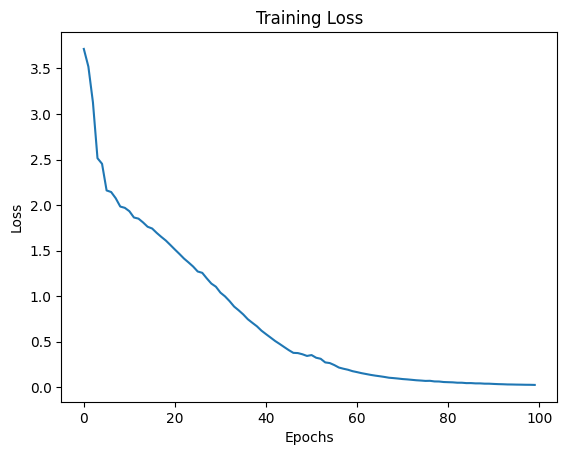

In [32]:
# Plotting training loss
import matplotlib.pyplot as plt
plt.plot(history_glorot_adam.history['loss'])
plt.title('Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()